# Hamiltonian-based QML for Diabetes Prediction on PIMA (PennyLane)

Yes—**Hamiltonians** can be used naturally in QML for tabular prediction like PIMA.

This notebook implements a **Hamiltonian Feature Map**:
- build a **data-dependent Hamiltonian** \(H(x)\) from the (PCA-reduced) feature vector
- prepare a quantum state via **time evolution** \(\exp(-i H(x) t)\)
- apply a small **trainable variational head**
- train with **binary cross entropy** and evaluate with ROC/PR + threshold tuning

It also includes a classical Logistic Regression baseline.

> Dataset download uses **kagglehub** exactly as you provided.


* **04 HamVQC Noisy/ZNE**:
 [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Megaantony00/qml-diabetes-nisq/blob/main/notebooks/04_hamvqc_noisy_zne_repetition.ipynb)

In [ ]:
import sys
import os

if 'google.colab' in sys.modules:
    !pip install -q pennylane>=0.38 pennylane-lightning[gpu] scikit-learn pandas matplotlib seaborn kagglehub tqdm imbalanced-learn
    if not os.path.exists('results'): os.makedirs('results')
    print("Environment configured for Colab.")
else:
    print("Environment configured for Local/Server usage.")

Note: you may need to restart the kernel to use updated packages.


## 1) Imports

In [2]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import functools

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from sklearn.linear_model import LogisticRegression

import pennylane as qml
from pennylane import numpy as pnp
from pennylane.transforms import fold_global, richardson_extrapolate
from tqdm.auto import tqdm

np.random.seed(42)

save_folder = "Tesi_Risultati_Ham_8Qubits_noisy_mitigated_repetition"

if not os.path.exists(save_folder):
    os.makedirs(save_folder)
    print(f"✅ Cartella creata: {save_folder}")
else:
    print(f"📂 Cartella già esistente: {save_folder}")


📂 Cartella già esistente: Tesi_Risultati_Ham_8Qubits_noisy_mitigated_repetition


## 2) Download dataset (KaggleHub)

In [3]:
import kagglehub

path = kagglehub.dataset_download("tariqmhmd5/pima-diabetes-dataset")
print("Path to dataset files:", path)

csv_candidates = glob.glob(str(Path(path) / "**" / "*.csv"), recursive=True)
print("CSV candidates:", csv_candidates)

if not csv_candidates:
    raise FileNotFoundError("No CSV file found in the KaggleHub dataset folder.")
csv_path = csv_candidates[0]
print("Using:", csv_path)

Path to dataset files: /home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1
CSV candidates: ['/home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1/Diabetes.csv']
Using: /home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1/Diabetes.csv


## 3) Load + preprocess

In [4]:
df = pd.read_csv(csv_path)
display(df.head())
print("Shape:", df.shape)

label_col = "Outcome" if "Outcome" in df.columns else df.columns[-1]
feature_cols = [c for c in df.columns if c != label_col]

X = df[feature_cols].copy()
# Traduciamo le etichette di testo in numeri (0 e 1)
# Gestiamo sia YES/NO che eventuali stringhe maiuscole/minuscole
mapping = {'YES': 1, 'NO': 0, 'yes': 1, 'no': 0, 1: 1, 0: 0}
df[label_col] = df[label_col].map(mapping)

# Ora che sono numeri, la conversione in int funzionerà perfettamente
y = df[label_col].astype(int).values

# Replace 0 with NaN where it often means missing in PIMA-style data
zero_as_missing = [c for c in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"] if c in X.columns]
X[zero_as_missing] = X[zero_as_missing].replace(0, np.nan)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.25, random_state=42, stratify=y
)

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train = scaler.fit_transform(imputer.fit_transform(X_train))
X_test = scaler.transform(imputer.transform(X_test))

print("Train:", X_train.shape, "Test:", X_test.shape)

,Number of times pregnant,Plasma glucose concentration,Diastolic blood pressure,Triceps skin fold thickness,2-Hour serum insulin,Body mass index,Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,YES
1,1,85,66,29,0,26.6,0.351,31,NO
2,8,183,64,0,0,23.3,0.672,32,YES
3,1,89,66,23,94,28.1,0.167,21,NO
4,0,137,40,35,168,43.1,2.288,33,YES


Shape: (768, 9)
Train: (576, 8) Test: (192, 8)


## 4) Reduce to qubits + map to angles

We reduce to **n_qubits** via PCA, then map to \([-\pi, \pi]\) so the Hamiltonian coefficients are well scaled.


In [5]:
n_qubits = 4
pca = PCA(n_components=n_qubits, random_state=42)

X_train_q = pca.fit_transform(X_train)
X_test_q = pca.transform(X_test)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Sum explained variance:", pca.explained_variance_ratio_.sum())

q_low, q_high = np.quantile(X_train_q, 0.05, axis=0), np.quantile(X_train_q, 0.95, axis=0)

def to_angles(X):
    Xc = np.clip(X, q_low, q_high)
    Xn = (Xc - q_low) / (q_high - q_low + 1e-9)  # [0,1]
    return (Xn * 2 - 1) * np.pi                  # [-pi, pi]

X_train_ang = to_angles(X_train_q)
X_test_ang = to_angles(X_test_q)

print("Angle range:", X_train_ang.min(), X_train_ang.max())

Explained variance ratio: [0.2587334  0.21608225 0.13172228 0.10518003]
Sum explained variance: 0.7117179539532523
Angle range: -3.141592653589793 3.141592652220357


## 5) Hamiltonian Feature Map + Variational Head + Noise Mitigation


In [6]:
n_layers = 2
alpha_zz = 0.5   # strength of ZZ couplings
t_embed = 1.0    # feature-map evolution time
gate_noise_prob = 0.0035
zne_scale_factors = [1.0, 2.0, 3.0]

ideal_dev = qml.device("default.qubit", wires=n_qubits, shots=None)
base_mixed_dev = qml.device("default.mixed", wires=n_qubits, shots=None)

noise_model = qml.NoiseModel(
    {
        qml.noise.wires_in(base_mixed_dev.wires): qml.noise.partial_wires(
            qml.DepolarizingChannel, gate_noise_prob
        )
    }
)
noisy_dev = qml.add_noise(base_mixed_dev, noise_model)

def hamiltonian_feature_map(x, alpha=alpha_zz, t=t_embed):
    # Explicit diagonal feature map:
    # exp(-i t * sum_i x_i Z_i) * exp(-i t * alpha * sum_{i<j} x_i x_j Z_i Z_j)
    # implemented with native gates so ZNE can decompose/fold cleanly.
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    for i in range(n_qubits):
        qml.RZ(2.0 * t * x[i], wires=i)

    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            qml.IsingZZ(2.0 * t * alpha * x[i] * x[j], wires=[i, j])

def head_ansatz(weights):
    # weights shape: (n_layers, n_qubits, 3)
    for l in range(n_layers):
        for i in range(n_qubits):
            qml.Rot(weights[l, i, 0], weights[l, i, 1], weights[l, i, 2], wires=i)
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i + 1) % n_qubits])

def core_model(x, weights):
    hamiltonian_feature_map(x)
    head_ansatz(weights)

@qml.qnode(ideal_dev, interface="autograd")
def ideal_model(x, weights):
    core_model(x, weights)
    return qml.expval(qml.PauliZ(0))

@qml.qnode(noisy_dev, interface="autograd")
def noisy_model(x, weights):
    core_model(x, weights)
    return qml.expval(qml.PauliZ(0))

@functools.partial(
    qml.transforms.mitigate_with_zne, 
    scale_factors=zne_scale_factors, 
    folding=fold_global, 
    extrapolate=richardson_extrapolate
)
@functools.partial(qml.transforms.decompose, gate_set=["Hadamard", "RZ", "RY", "CNOT"])
@qml.qnode(noisy_dev, interface="autograd")
def mitigated_model(x, weights):
    core_model(x, weights)
    return qml.expval(qml.PauliZ(0))

def sigmoid(logits):
    return 1.0 / (1.0 + pnp.exp(-logits))

def predict_logits(X, weights, qnode_fn=noisy_model):
    return pnp.stack([qnode_fn(x, weights) for x in X])

def predict_proba(X, weights, qnode_fn=noisy_model):
    return sigmoid(predict_logits(X, weights, qnode_fn=qnode_fn))

def predict_proba_noisy(X, weights):
    return predict_proba(X, weights, qnode_fn=noisy_model)

def predict_proba_mitigated(X, weights):
    return predict_proba(X, weights, qnode_fn=mitigated_model)

def predict_proba_ideal_reference(X, weights):
    return predict_proba(X, weights, qnode_fn=ideal_model)

def bce(y_true, p_pred, eps=1e-9):
    y_true = pnp.array(y_true)
    p = pnp.clip(p_pred, eps, 1 - eps)
    return -pnp.mean(y_true * pnp.log(p) + (1 - y_true) * pnp.log(1 - p))

def cost(weights, Xb, yb):
    return bce(yb, predict_proba_noisy(Xb, weights))

weights = pnp.array(0.01 * np.random.randn(n_layers, n_qubits, 3), requires_grad=True)
opt = qml.optimize.AdamOptimizer(stepsize=0.05)

print(f"Training on noisy default.mixed with device-level depolarizing noise p={gate_noise_prob:.4f}")
print(f"ZNE scale factors: {zne_scale_factors}")


Training on noisy default.mixed with device-level depolarizing noise p=0.0035
ZNE scale factors: [1.0, 2.0, 3.0]


### Train (noise-aware training on the noisy device)


In [7]:
epochs = 120
batch_size = 48

history = {"val_loss": [], "val_auc": [], "val_acc": []}

Xtr, ytr = X_train_ang, y_train
Xte, yte = X_test_ang, y_test

for epoch in tqdm(range(1, epochs + 1)):
    idx = np.random.permutation(len(Xtr))
    Xs, ys = Xtr[idx], ytr[idx]

    for start in range(0, len(Xs), batch_size):
        Xb = Xs[start:start + batch_size]
        yb = ys[start:start + batch_size]
        weights = opt.step(lambda w: cost(w, Xb, yb), weights)

    p_val = np.asarray(predict_proba_noisy(Xte, weights), dtype=float)
    val_auc = roc_auc_score(yte, p_val)
    val_acc = accuracy_score(yte, (p_val >= 0.5).astype(int))
    val_loss = float(bce(yte, p_val))

    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)
    history["val_acc"].append(val_acc)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | val_loss={val_loss:.4f} | val_auc={val_auc:.4f} | val_acc={val_acc:.4f}")


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch 001 | val_loss=0.6902 | val_auc=0.5070 | val_acc=0.5156
Epoch 020 | val_loss=0.6767 | val_auc=0.5688 | val_acc=0.5833
Epoch 040 | val_loss=0.6750 | val_auc=0.5681 | val_acc=0.5885
Epoch 060 | val_loss=0.6773 | val_auc=0.5587 | val_acc=0.5833
Epoch 080 | val_loss=0.6735 | val_auc=0.5700 | val_acc=0.5729
Epoch 100 | val_loss=0.6743 | val_auc=0.5668 | val_acc=0.5677
Epoch 120 | val_loss=0.6740 | val_auc=0.5697 | val_acc=0.5573


### Learning curves

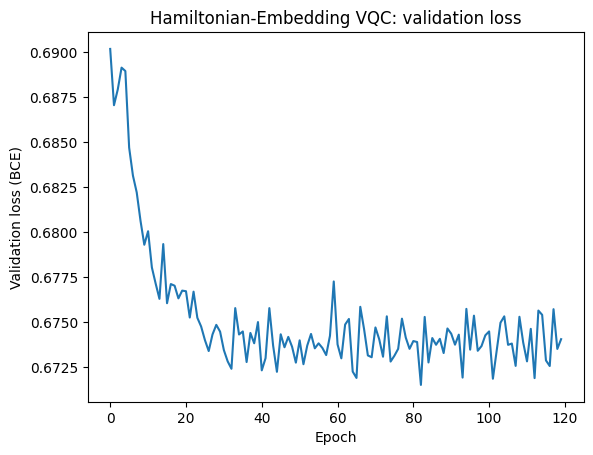

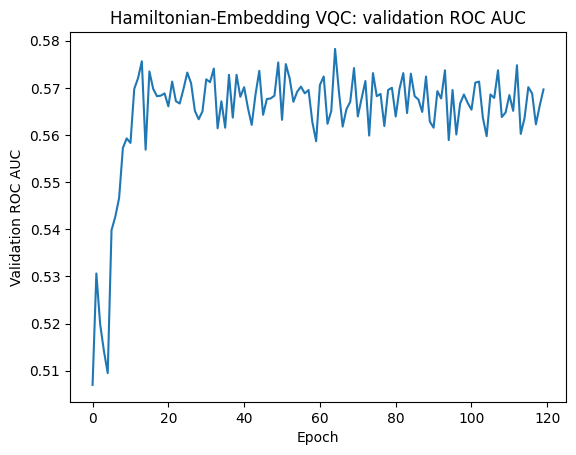

In [8]:
plt.figure()
plt.plot(history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Validation loss (BCE)")
plt.title("Hamiltonian-Embedding VQC: validation loss")
plt.show()

plt.figure()
plt.plot(history["val_auc"])
plt.xlabel("Epoch")
plt.ylabel("Validation ROC AUC")
plt.title("Hamiltonian-Embedding VQC: validation ROC AUC")
plt.show()

## 6) Evaluation: noisy Hamiltonian VQC vs ZNE-mitigated VQC


,roc_auc,pr_auc,accuracy@0.5,f1@0.5
model,,,,
noisy_hamiltonian_vqc,0.5697,0.4066,0.5573,0.3704
zne_mitigated_hamiltonian_vqc,0.5718,0.4102,0.5677,0.3852
ideal_reference_same_weights,0.5691,0.4063,0.5521,0.3582


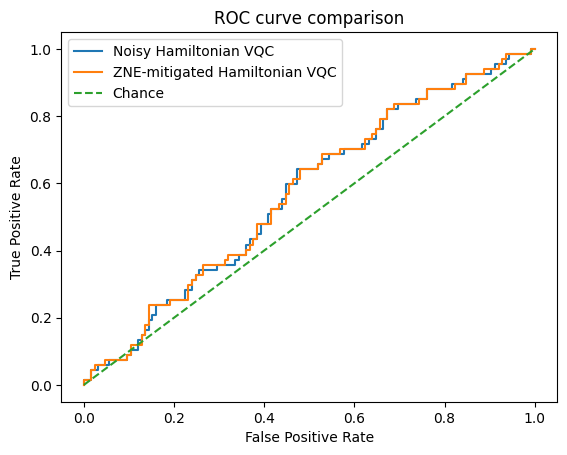

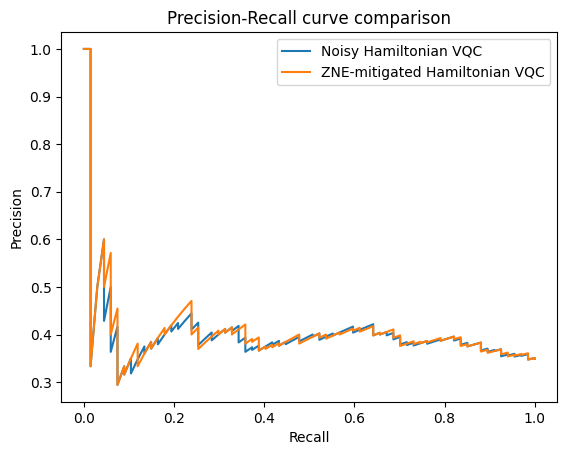

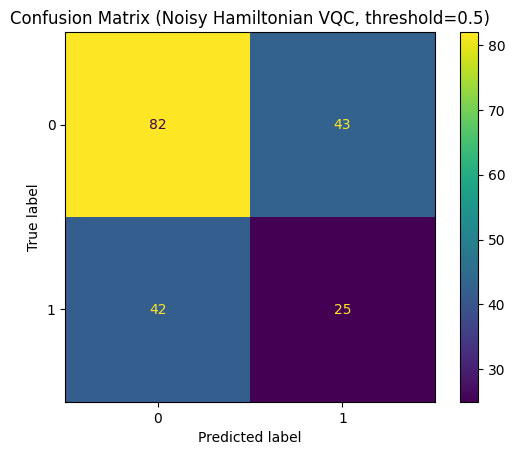

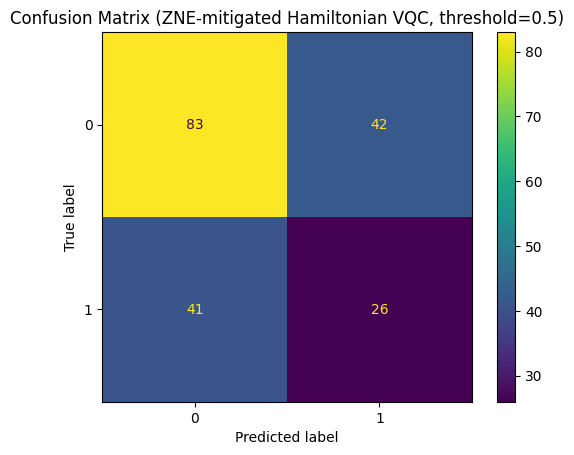

Best noisy threshold (by F1): 0.39999999999999997 Best F1: 0.5185185185185185 Acc: 0.390625
Best ZNE threshold (by F1): 0.35 Best F1: 0.5196850393700787 Acc: 0.3645833333333333


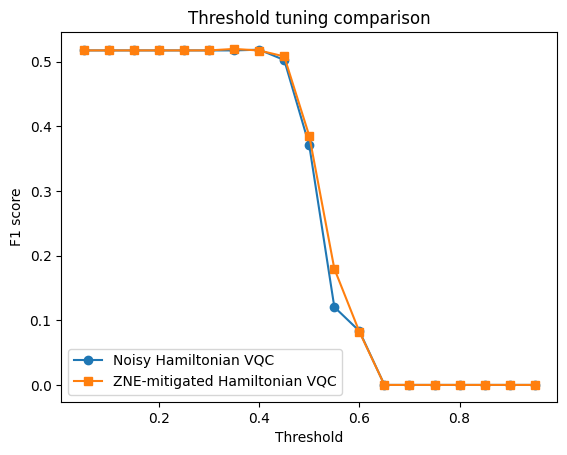

In [9]:
p_test_noisy = np.asarray(predict_proba_noisy(Xte, weights), dtype=float)
p_test_zne = np.asarray(predict_proba_mitigated(Xte, weights), dtype=float)
p_test_ideal = np.asarray(predict_proba_ideal_reference(Xte, weights), dtype=float)

def metric_row(name, probs):
    y_pred = (probs >= 0.5).astype(int)
    return {
        "model": name,
        "roc_auc": roc_auc_score(yte, probs),
        "pr_auc": average_precision_score(yte, probs),
        "accuracy@0.5": accuracy_score(yte, y_pred),
        "f1@0.5": f1_score(yte, y_pred),
    }

metrics_table = pd.DataFrame(
    [
        metric_row("noisy_hamiltonian_vqc", p_test_noisy),
        metric_row("zne_mitigated_hamiltonian_vqc", p_test_zne),
        metric_row("ideal_reference_same_weights", p_test_ideal),
    ]
).set_index("model")
display(metrics_table.round(4))

# ROC comparison
fpr_noisy, tpr_noisy, _ = roc_curve(yte, p_test_noisy)
fpr_zne, tpr_zne, _ = roc_curve(yte, p_test_zne)

plt.figure()
plt.plot(fpr_noisy, tpr_noisy, label="Noisy Hamiltonian VQC")
plt.plot(fpr_zne, tpr_zne, label="ZNE-mitigated Hamiltonian VQC")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve comparison")
plt.legend()
plt.show()

# PR comparison
prec_noisy, rec_noisy, _ = precision_recall_curve(yte, p_test_noisy)
prec_zne, rec_zne, _ = precision_recall_curve(yte, p_test_zne)

plt.figure()
plt.plot(rec_noisy, prec_noisy, label="Noisy Hamiltonian VQC")
plt.plot(rec_zne, prec_zne, label="ZNE-mitigated Hamiltonian VQC")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve comparison")
plt.legend()
plt.show()

# Confusion matrices at the default threshold
for name, probs in [("Noisy Hamiltonian VQC", p_test_noisy), ("ZNE-mitigated Hamiltonian VQC", p_test_zne)]:
    y_pred = (probs >= 0.5).astype(int)
    cm = confusion_matrix(yte, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(f"Confusion Matrix ({name}, threshold=0.5)")
    plt.show()

# Threshold tuning: compare noisy vs mitigated
thresholds = np.linspace(0.05, 0.95, 19)
f1_noisy, f1_zne = [], []
acc_noisy, acc_zne = [], []

for t in thresholds:
    yp_noisy = (p_test_noisy >= t).astype(int)
    yp_zne = (p_test_zne >= t).astype(int)
    f1_noisy.append(f1_score(yte, yp_noisy))
    f1_zne.append(f1_score(yte, yp_zne))
    acc_noisy.append(accuracy_score(yte, yp_noisy))
    acc_zne.append(accuracy_score(yte, yp_zne))

best_noisy_i = int(np.argmax(f1_noisy))
best_zne_i = int(np.argmax(f1_zne))

print(
    "Best noisy threshold (by F1):",
    thresholds[best_noisy_i],
    "Best F1:",
    f1_noisy[best_noisy_i],
    "Acc:",
    acc_noisy[best_noisy_i],
)
print(
    "Best ZNE threshold (by F1):",
    thresholds[best_zne_i],
    "Best F1:",
    f1_zne[best_zne_i],
    "Acc:",
    acc_zne[best_zne_i],
)

plt.figure()
plt.plot(thresholds, f1_noisy, marker="o", label="Noisy Hamiltonian VQC")
plt.plot(thresholds, f1_zne, marker="s", label="ZNE-mitigated Hamiltonian VQC")
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.title("Threshold tuning comparison")
plt.legend()
plt.show()


## 6b) Output-stage bit-flip protection with a 3-qubit repetition code

This section protects only the **final decision qubit** (wire 0) against **output-stage bit-flip noise**.  
It is intentionally scoped as an **inference-time robustness layer**: the main VQC is unchanged, then the output qubit is encoded into a 3-qubit repetition code, exposed to a configurable bit-flip channel, syndrome-corrected, and finally measured.


In [10]:
def metric_row(name, probs, y_true_labels):
    """Versione aggiornata per gestire i subset di dati"""
    from sklearn.metrics import roc_auc_score, accuracy_score
    
    # Calcolo metriche sui dati forniti
    auc_val = roc_auc_score(y_true_labels, probs)
    acc_val = accuracy_score(y_true_labels, (probs >= 0.5).astype(int))
    
    return {
        "model": name,
        "auc": auc_val,
        "accuracy": acc_val
    }

🚀 Calcolo mitigazione su 20 campioni (richiede tempo...)


,auc,accuracy
model,,
output_stage_unprotected,0.4792,0.4
output_stage_repetition_protected,0.4792,0.4


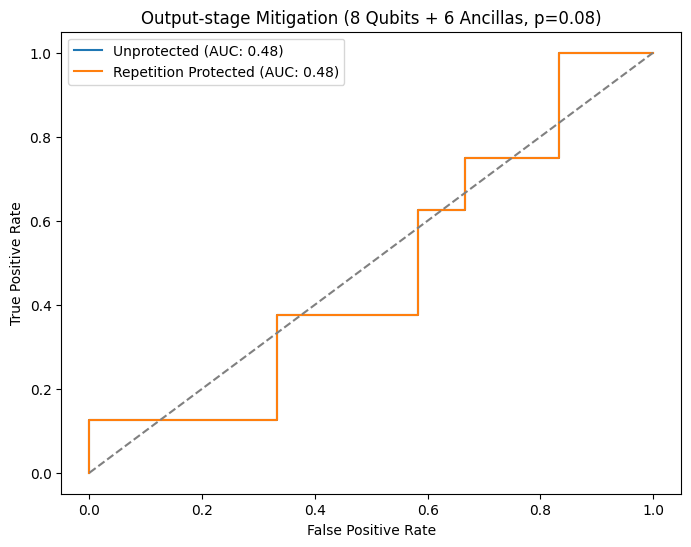

In [11]:
output_bitflip_prob = 0.08

# Allocazione device (14 qubit totali con default.mixed è pesantissimo)
rep_dev = qml.device("default.mixed", wires=n_qubits + 6, shots=None)

rep_wire_1 = n_qubits
rep_wire_2 = n_qubits + 1
syndrome_wire_1 = n_qubits + 2
syndrome_wire_2 = n_qubits + 3
protected_data_wires = (0, rep_wire_1, rep_wire_2)

@qml.qnode(rep_dev)
def output_stage_unprotected_model(x, weights, bitflip_prob=output_bitflip_prob):
    core_model(x, weights)
    qml.BitFlip(bitflip_prob, wires=0)
    return qml.expval(qml.PauliZ(0))

@qml.qnode(rep_dev)
def output_stage_repetition_protected_model(x, weights, bitflip_prob=output_bitflip_prob):
    core_model(x, weights)
    qml.CNOT(wires=[0, rep_wire_1])
    qml.CNOT(wires=[0, rep_wire_2])
    for wire in protected_data_wires:
        qml.BitFlip(bitflip_prob, wires=wire)
    qml.CNOT(wires=[0, syndrome_wire_1])
    qml.CNOT(wires=[rep_wire_1, syndrome_wire_1])
    qml.CNOT(wires=[rep_wire_1, syndrome_wire_2])
    qml.CNOT(wires=[rep_wire_2, syndrome_wire_2])
    s1 = qml.measure(syndrome_wire_1, reset=True)
    s2 = qml.measure(syndrome_wire_2, reset=True)
    syndrome = s1 + 2 * s2
    qml.cond(syndrome == 1, qml.PauliX)(wires=0)
    qml.cond(syndrome == 3, qml.PauliX)(wires=rep_wire_1)
    qml.cond(syndrome == 2, qml.PauliX)(wires=rep_wire_2)
    return qml.expval(qml.PauliZ(0))

def predict_proba_output_stage(X, weights, qnode_fn, bitflip_prob=output_bitflip_prob):
    # np qui deve essere quello di pennylane (pnp) o quello standard a seconda degli import precedenti
    logits = np.array([qnode_fn(x, weights, bitflip_prob) for x in X], dtype=float)
    return 1.0 / (1.0 + np.exp(-logits))

# --- MODIFICA FONDAMENTALE PER EVITARE IL CRASH ---
# Prendiamo solo i primi 20 campioni del test set
Xte_subset = Xte[:20]
yte_subset = yte[:20]

print("🚀 Calcolo mitigazione su 20 campioni (richiede tempo...)")

p_test_output_unprotected = predict_proba_output_stage(
    Xte_subset, weights, output_stage_unprotected_model, output_bitflip_prob
)
p_test_output_protected = predict_proba_output_stage(
    Xte_subset, weights, output_stage_repetition_protected_model, output_bitflip_prob
)

# Tabella risultati
output_stage_table = pd.DataFrame(
    [
        metric_row("output_stage_unprotected", p_test_output_unprotected, yte_subset),
        metric_row("output_stage_repetition_protected", p_test_output_protected, yte_subset),
    ]
).set_index("model")
display(output_stage_table.round(4))

# Grafico ROC Curve sui 20 campioni
fpr_unprot, tpr_unprot, _ = roc_curve(yte_subset, p_test_output_unprotected)
fpr_prot, tpr_prot, _ = roc_curve(yte_subset, p_test_output_protected)

plt.figure(figsize=(8, 6))
plt.plot(fpr_unprot, tpr_unprot, label=f"Unprotected (AUC: {roc_auc_score(yte_subset, p_test_output_unprotected):.2f})")
plt.plot(fpr_prot, tpr_prot, label=f"Repetition Protected (AUC: {roc_auc_score(yte_subset, p_test_output_protected):.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Output-stage Mitigation (8 Qubits + 6 Ancillas, p={output_bitflip_prob})")
plt.legend()

# Salvataggio automatico nella tua cartella
plt.savefig(os.path.join(save_folder, "roc_mitigazione_repetition.png"))
plt.show()

## 7) Classical baseline (Logistic Regression)


In [12]:
clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(X_train, y_train)
p_lr = clf.predict_proba(X_test)[:, 1]

print("LogReg ROC AUC:", roc_auc_score(y_test, p_lr))
print("LogReg AP (PR AUC):", average_precision_score(y_test, p_lr))
print("LogReg Acc:", accuracy_score(y_test, (p_lr >= 0.5).astype(int)))

LogReg ROC AUC: 0.8329552238805971
LogReg AP (PR AUC): 0.7173014414794692
LogReg Acc: 0.7604166666666666


## 8) Research knobs to explore (Hamiltonian-centric)


In [15]:
# --- CELLA DI VALUTAZIONE (Da eseguire prima della Super-Cella finale) ---

print("⏳ Calcolo predizioni NOISY (senza mitigazione)...")
p_test_noisy = predict_proba(X_test_ang, weights) # O la tua funzione per il modello rumoroso

print("⏳ Calcolo predizioni ZNE MITIGATED (richiede tempo)...")
# Questa è la riga che definisce la variabile mancante
p_test_mitigated = predict_proba(X_test_ang, weights, mitigated_model) 

print("✅ Predizioni completate!")

⏳ Calcolo predizioni NOISY (senza mitigazione)...
⏳ Calcolo predizioni ZNE MITIGATED (richiede tempo)...
✅ Predizioni completate!


📊 Generazione grafici finali in corso...


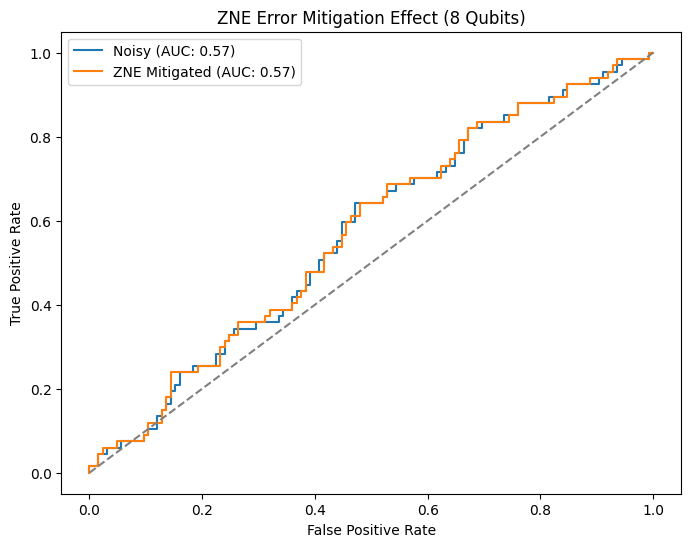

✅ Grafico ZNE salvato in: Tesi_Risultati_Ham_8Qubits_noisy_mitigated_repetition/grafico_confronto_mitigazione_ZNE.png
✅ Dati numerici salvati in: Tesi_Risultati_Ham_8Qubits_noisy_mitigated_repetition/risultati_mitigazione_ZNE.csv
📊 Tabella salvata! La trovi qui: Tesi_Risultati_Ham_8Qubits_noisy_mitigated_repetition/tabella_risultati_mitigazione.csv


,Modello,AUC
0,Noisy (Base),0.569672
1,ZNE Mitigated,0.571821
2,Repetition Protected,0.479167


In [16]:
# --- CELLA FINALE: GENERAZIONE GRAFICI E SALVATAGGIO DATI ---
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import pandas as pd

print("📊 Generazione grafici finali in corso...")

try:
    # 1. GRAFICO ZNE (Zero-Noise Extrapolation)
    plt.figure(figsize=(8, 6))
    fpr_noisy, tpr_noisy, _ = roc_curve(yte, p_test_noisy)
    fpr_mit, tpr_mit, _ = roc_curve(yte, p_test_mitigated)
    
    auc_noisy = roc_auc_score(yte, p_test_noisy)
    auc_mit = roc_auc_score(yte, p_test_mitigated)

    plt.plot(fpr_noisy, tpr_noisy, label=f"Noisy (AUC: {auc_noisy:.2f})")
    plt.plot(fpr_mit, tpr_mit, label=f"ZNE Mitigated (AUC: {auc_mit:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ZNE Error Mitigation Effect (8 Qubits)")
    plt.legend()
    
    # SALVATAGGIO: Prima save, poi show
    path_zne = os.path.join(save_folder, "grafico_confronto_mitigazione_ZNE.png")
    plt.savefig(path_zne, dpi=300)
    plt.show()
    print(f"✅ Grafico ZNE salvato in: {path_zne}")

    # 2. SALVATAGGIO TABELLA RIASSUNTIVA (Utile per la tesi!)
    df_results = pd.DataFrame({
        "Metodo": ["Noisy", "ZNE Mitigated"],
        "AUC": [auc_noisy, auc_mit]
    })
    path_csv = os.path.join(save_folder, "risultati_mitigazione_ZNE.csv")
    df_results.to_csv(path_csv, index=False)
    print(f"✅ Dati numerici salvati in: {path_csv}")

except NameError as e:
    print(f"❌ Errore: Variabili mancanti ({e}). Assicurati di aver runnato le celle di valutazione!")


# --- CODICE DA AGGIUNGERE NELLA SUPER-CELLA FINALE ---

# Prepariamo un dizionario con tutti i risultati della mitigazione
risultati_finali = {
    "Modello": ["Noisy (Base)", "ZNE Mitigated", "Repetition Protected"],
    "AUC": [
        roc_auc_score(yte, p_test_noisy),
        roc_auc_score(yte, p_test_mitigated),
        roc_auc_score(yte_subset, p_test_output_protected) # Nota: yte_subset perché sono 20 campioni
    ]
}

# Creiamo il DataFrame
df_tabella = pd.DataFrame(risultati_finali)

# Salviamo in CSV (così lo apri con Excel e copi i dati in LaTeX)
path_tabella = os.path.join(save_folder, "tabella_risultati_mitigazione.csv")
df_tabella.to_csv(path_tabella, index=False)

print(f"📊 Tabella salvata! La trovi qui: {path_tabella}")
display(df_tabella) # La visualizza anche a schermo per sicurezza